In [2]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, RSA, load_img_natraster, print_wise, TimeSeries, get_relevant_output_layers
from general_utils.dRSA import across_areas_dRSA
from general_utils.II import InformationImbalance, compare_similarity_metrics

In [126]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'paul'
    date: str =  "230204"#'220226to527' # '220226to527' #
    model_name: str = 'vit_l_16'
    layer_name: str = 'blocks.16.mlp.fc2'
    pkg: str = 'timm'
    img_size: int = 384
    brain_area: str = 'AIT'
    max_size: int = 2500
    n_trials: int = 4377
    step_samples: int = 100 # of how many samples we jump every time
    similarity_measure: str = 'cosine'
    pooling: str = 'mean'
    new_fs: int = 100 # Hz
    n_iter: int = 100 # how many time we repeat the sampling
    RDM_metric1: str = 'euclidean'
    RDM_metric2: str = 'cosine_cnt'
    RSA_metric: str = 'correlation'
    fig_dir: str = "/Users/tizianocausin/gdrive/figures_papers/research_plan"
    title_fontsize=25
    labels_fontsize = 20
    ticks_fontsize = 15
    legend_fontsize=13
    k=1
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
brain_areas = ['V1', 'V2', 'V3', 'PIT', 'CIT', 'AIT']

In [4]:
import pickle as pkl
with open("/Users/tizianocausin/Desktop/B2A_layers_list_cos_temp.pkl", "rb") as f:
    B2A_cos = pkl.load(f)

In [19]:
from general_utils.utils import load_npz_as_dict
def plot_metrics(paths, layers, cfg, ylim = None, save=False):
    n_layers = len(layers)
    ncols = 4
    nrows = int(np.ceil(n_layers / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4*ncols, 3*nrows),
        sharex=True, sharey=True
    )
    axes = axes.flatten()
    with open("/Users/tizianocausin/Desktop/A2B_layers_list_euc_temp.pkl", "rb") as f:
        A2B_euc = pkl.load(f)
    with open("/Users/tizianocausin/Desktop/B2A_layers_list_euc_temp.pkl", "rb") as f:
        B2A_euc = pkl.load(f)
    with open("/Users/tizianocausin/Desktop/A2B_layers_list_cos_temp.pkl", "rb") as f:
        A2B_cos = pkl.load(f)
    with open("/Users/tizianocausin/Desktop/B2A_layers_list_cos_temp.pkl", "rb") as f:
        B2A_cos = pkl.load(f)
    with open("/Users/tizianocausin/Desktop/A2B_layers_list_cos-euc_temp.pkl", "rb") as f:
        A2B_euccos = pkl.load(f)
    with open("/Users/tizianocausin/Desktop/B2A_layers_list_cos-euc_temp.pkl", "rb") as f:
        B2A_euccos = pkl.load(f)
    for idx, (ax, l) in enumerate(zip(axes, layers)):
        file_name = (
            f"subsampling_{cfg.new_fs}Hz_{cfg.step_samples}-{cfg.max_size}_"
            f"{cfg.n_iter}iter_{cfg.monkey_name}_{cfg.date}_"
            f"{cfg.brain_area}_{cfg.RDM_metric1}_{cfg.model_name}_{cfg.img_size}_{l}.npz"
        )
        results_path = f"{paths['livingstone_lab']}/tiziano/results/{file_name}"
        iter_dict = load_npz_as_dict(results_path)
        ax.set_title(l, fontsize=12)
        l_m1, = ax.plot(
            iter_dict[str(cfg.n_trials)],
            color="tab:blue",
            linestyle="--",
            linewidth=2,
        )
        file_name = (
            f"subsampling_{cfg.new_fs}Hz_{cfg.step_samples}-{cfg.max_size}_"
            f"{cfg.n_iter}iter_{cfg.monkey_name}_{cfg.date}_"
            f"{cfg.brain_area}_{cfg.RDM_metric2}_{cfg.model_name}_{cfg.img_size}_{l}.npz"
        )
        results_path = f"{paths['livingstone_lab']}/tiziano/results/{file_name}"
        iter_dict = load_npz_as_dict(results_path)
        l_m2, = ax.plot(
            iter_dict[str(cfg.n_trials)],
            color="tab:blue",
            linewidth=2,
        )
        ax.spines["left"].set_linewidth(2.5)
        color = "tab:blue"
        ax.spines["left"].set_color(color)
        ax.tick_params(axis="y", colors=color)
        ax.yaxis.label.set_color(color)

        ax_right = ax.twinx()
        color = "tab:red"
        ax_right.spines["right"].set_color(color)
        ax_right.tick_params(axis="y", colors=color)
        ax_right.yaxis.label.set_color(color)
        l_m1_A2B, = ax_right.plot(A2B_euc[idx].get_array(), linestyle="--", color='tab:orange', alpha=.7, linewidth=2)
        l_m1_B2A, = ax_right.plot(B2A_euc[idx].get_array(), linestyle="--", color='tab:red', linewidth=2)
        l_m2_A2B, = ax_right.plot(B2A_cos[idx].get_array(), color='tab:orange', alpha=.7, linewidth=2)
        l_m2_B2A, = ax_right.plot(A2B_cos[idx].get_array(), color='tab:red', linewidth=2)
        l_m3_A2B, = ax_right.plot(B2A_euccos[idx].get_array(), linestyle=":", color='orange', linewidth=2)
        l_m3_B2A, = ax_right.plot(A2B_euccos[idx].get_array(), linestyle=":", color='red', linewidth=2)
        ax_right.spines["right"].set_linewidth(2.5)
        ax_right.set_ylim([.4, 1.05])
        if idx % ncols != ncols - 1:
            ax_right.set_yticks([.4, .6, .8, 1.0])
            ax_right.set_yticklabels([])
            ax_right.set_ylabel("")
        else:
            ax_right.tick_params(axis='both', labelsize=15)

    # remove unused axes
    for ax in axes[len(layers):]:
        ax.axis("off")

    fig.supxlabel("Time from image onset (ms)", fontsize=20)
    fig.supylabel("RSA Similarity", fontsize=20, color='tab:blue')
    fig.suptitle(f"Brain area: {cfg.brain_area}", fontsize=27)
    fig.tight_layout()
    handles = [
        l_m1,
        l_m2,
        l_m1_A2B,
        l_m1_B2A,
        l_m2_A2B,
        l_m2_B2A,
        l_m3_A2B, 
        l_m3_B2A
    ]

    labels = [
        cfg.RDM_metric1,
        cfg.RDM_metric2,
        f"{chr(916)}(neural {chr(8594)} model) {cfg.RDM_metric1}",
        f"{chr(916)}(model {chr(8594)} neural) {cfg.RDM_metric1}",
        f"{chr(916)}(neural {chr(8594)} model) {cfg.RDM_metric2}",
        f"{chr(916)}(model {chr(8594)} neural) {cfg.RDM_metric2}",
        f"{chr(916)}(neural {chr(8594)} model) {cfg.RDM_metric1}-{cfg.RDM_metric2}",
        f"{chr(916)}(model {chr(8594)} neural) {cfg.RDM_metric1}-{cfg.RDM_metric2}",
    ]
    fig.legend(handles, labels,fontsize=12, bbox_to_anchor=(0.98, 0.90))
    # make space on the right for the legend
    fig.tight_layout(rect=[0.03, 0, 0.80, .97])
    fig.text(
        0.85, 0.5,                  # x, y in figure coordinates
        "Information Imbalance",
        va="center",
        ha="right",
        rotation=-90,
        fontsize=20,
        color='tab:red'
    )
    # ax.set_xticks(xtickspos)           # positions of ticks
    # ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
    if ylim is not None:
        for ax in axes[:n_layers]:
            ax.set_ylim(ylim[0], ylim[1])
    xtickspos = range(0, len(iter_dict[str(cfg.n_trials)])+1, 10)       
    for ax in axes[:n_layers]:  # only the used axes
        ax.set_xticks(xtickspos)
        ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
        ax.tick_params(axis='both', labelsize=15)
        # ax_right = ax.twinx()
        # ax_right.tick_params(axis='right', labelsize=15)
    if save==True:
        return fig, axes
    else:
        plt.show()


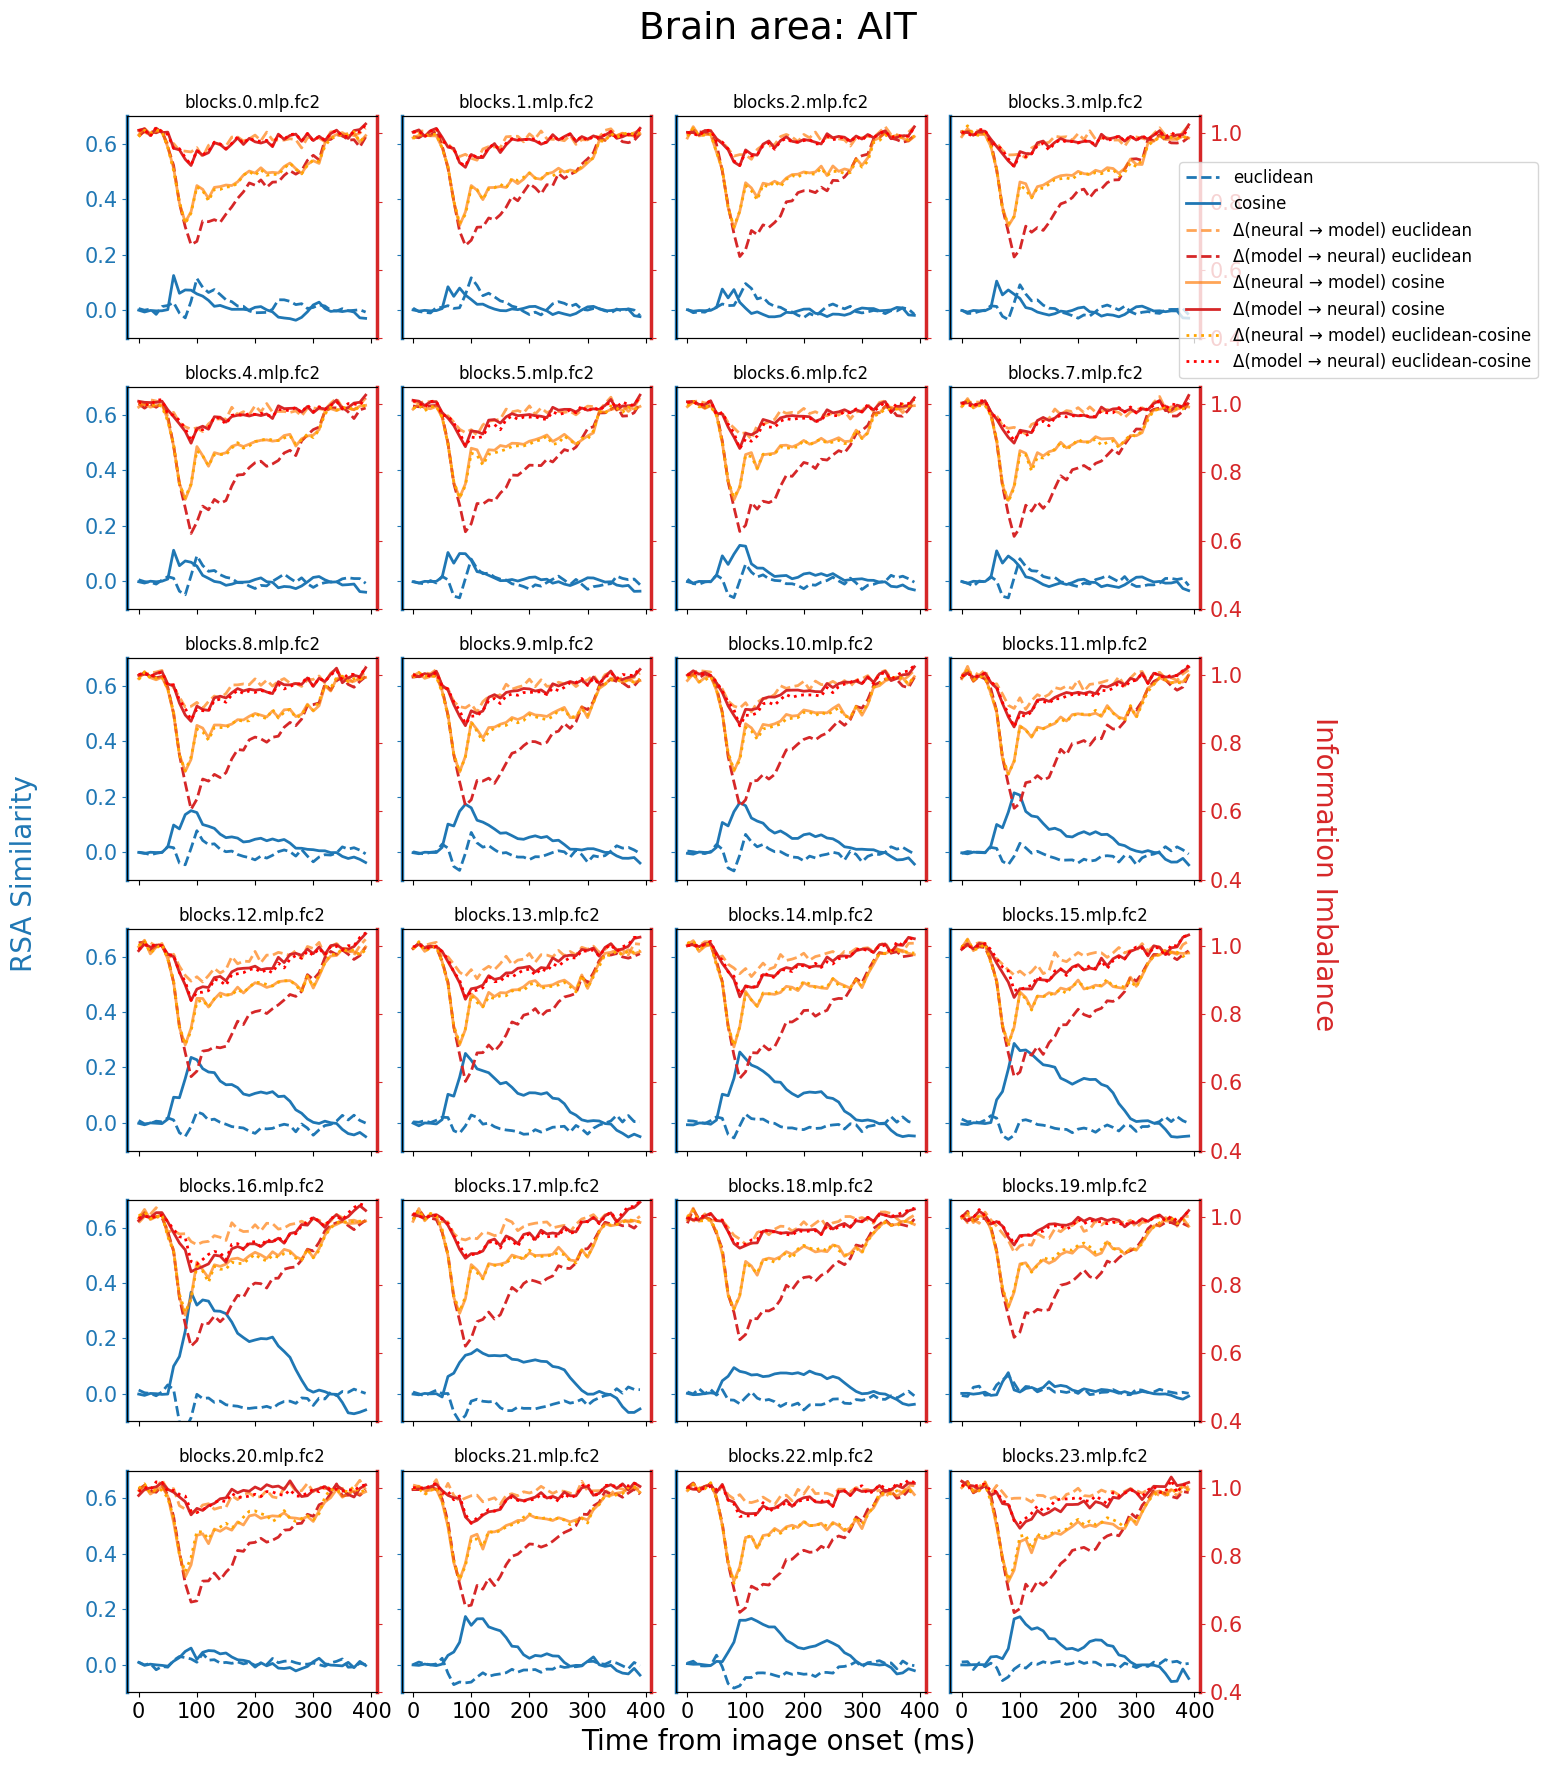

In [20]:
plot_metrics(paths, layers, cfg, ylim=[-.1, .7])

In [ ]:
def load_and_plot_dRSA_II(cfg, idx, l, ax, ncols):
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{cfg.k}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{cfg.k}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_dRSA = f"{paths['livingstone_lab']}/tiziano/results/static_dRSA_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"    
    A2B = np.load(save_name_A2B)["arr_0"]
    B2A = np.load(save_name_B2A)["arr_0"]
    drsa = np.load(save_name_dRSA)["arr_0"]
    ax.set_title(l, fontsize=12)
    l_m1, = ax.plot(
        drsa,
        color="tab:blue",
        linestyle="-",
        linewidth=2,
    )
    
    ax.spines["left"].set_linewidth(2.5)
    color = "tab:blue"
    ax.spines["left"].set_color(color)
    ax.tick_params(axis="y", colors=color)
    ax.yaxis.label.set_color(color)

    ax_right = ax.twinx()
    color = "tab:red"
    ax_right.spines["right"].set_color(color)
    ax_right.tick_params(axis="y", colors=color)
    ax_right.yaxis.label.set_color(color)
    l_m1_A2B, = ax_right.plot(A2B, color='tab:orange', alpha=.7, linewidth=2)
    l_m1_B2A, = ax_right.plot(B2A, color='tab:red', alpha=.7, linewidth=2)
    
    ax_right.spines["right"].set_linewidth(2.5)
    ax_right.set_ylim([.4, 1.05])
    if idx % ncols != ncols - 1:
        ax_right.set_yticks([.4, .6, .8, 1.0])
        ax_right.set_yticklabels([])
        ax_right.set_ylabel("")
    else:
        ax_right.tick_params(axis='both', labelsize=15)
    return l_m1, l_m1_A2B, l_m1_B2A, drsa


def new_plot_metrics(paths, layers, cfg, ylim = None, save=False):
    n_layers = len(layers)
    ncols = 4
    nrows = int(np.ceil(n_layers / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4*ncols, 3*nrows),
        sharex=True, sharey=True
    )
    axes = axes.flatten()
    

    for idx, (ax, l) in enumerate(zip(axes, layers)):
        l_m1, l_m1_A2B, l_m1_B2A, drsa = load_and_plot_dRSA_II(cfg, idx, l, ax, ncols) 

    # remove unused axes
    for ax in axes[len(layers):]:
        ax.axis("off")

    fig.supxlabel("Time from image onset (ms)", fontsize=20)
    fig.supylabel("RSA Similarity", fontsize=20, color='tab:blue')
    fig.suptitle(f"Brain area: {cfg.brain_area}", fontsize=27)
    fig.tight_layout()
    handles = [
        l_m1,
        l_m1_A2B,
        l_m1_B2A,
    ]

    labels = [
        "static dRSA",
        f"{chr(916)}(neural {chr(8594)} model) {cfg.signal_RDM_metric}-{cfg.model_RDM_metric}",
        f"{chr(916)}(model {chr(8594)} neural) {cfg.signal_RDM_metric}-{cfg.model_RDM_metric}",
    ]
    fig.legend(handles, labels,fontsize=12, bbox_to_anchor=(0.98, 0.90))
    # make space on the right for the legend
    fig.tight_layout(rect=[0.03, 0, 0.80, .97])
    fig.text(
        0.85, 0.5,                  # x, y in figure coordinates
        "Information Imbalance",
        va="center",
        ha="right",
        rotation=-90,
        fontsize=20,
        color='tab:red'
    )
    # ax.set_xticks(xtickspos)           # positions of ticks
    # ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
    if ylim is not None:
        for ax in axes[:n_layers]:
            ax.set_ylim(ylim[0], ylim[1])
    xtickspos = range(0, len(drsa)+1, 10)       
    for ax in axes[:n_layers]:  # only the used axes
        ax.set_xticks(xtickspos)
        ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
        ax.tick_params(axis='both', labelsize=15)
        # ax_right = ax.twinx()
        # ax_right.tick_params(axis='right', labelsize=15)
    if save==True:
        return fig, axes
    else:
        plt.show()


In [ ]:
for i_mt in [cfg.RDM_metric1, cfg.RDM_metric2]:
    for j_mt in [cfg.RDM_metric1, cfg.RDM_metric2]:
        

AttributeError: 'Cfg' object has no attribute 'signal_RDM_metric'

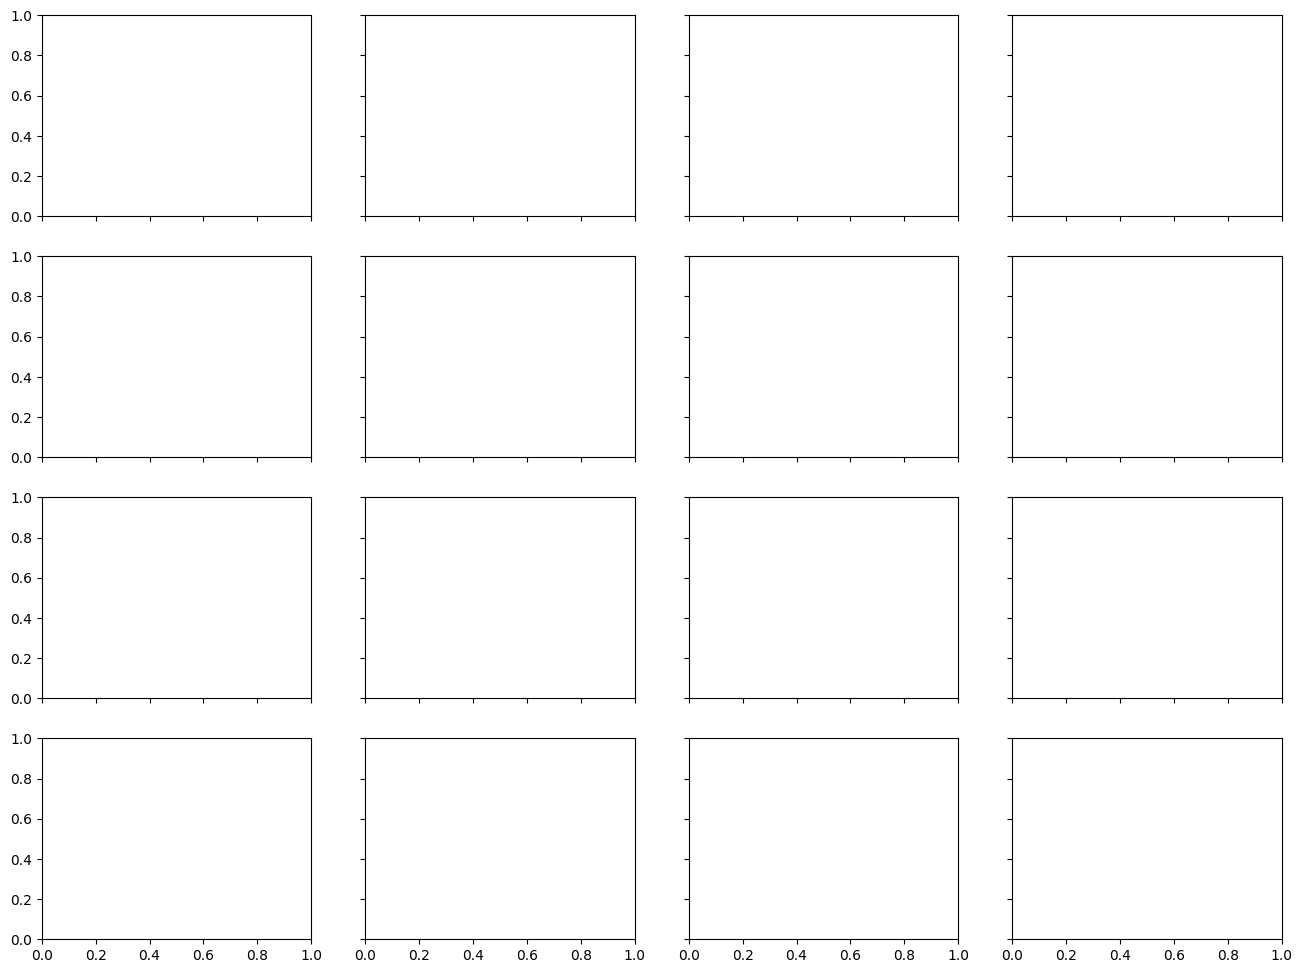

In [101]:
new_plot_metrics(paths, layers[:13], cfg, ylim=[-.1, .7])

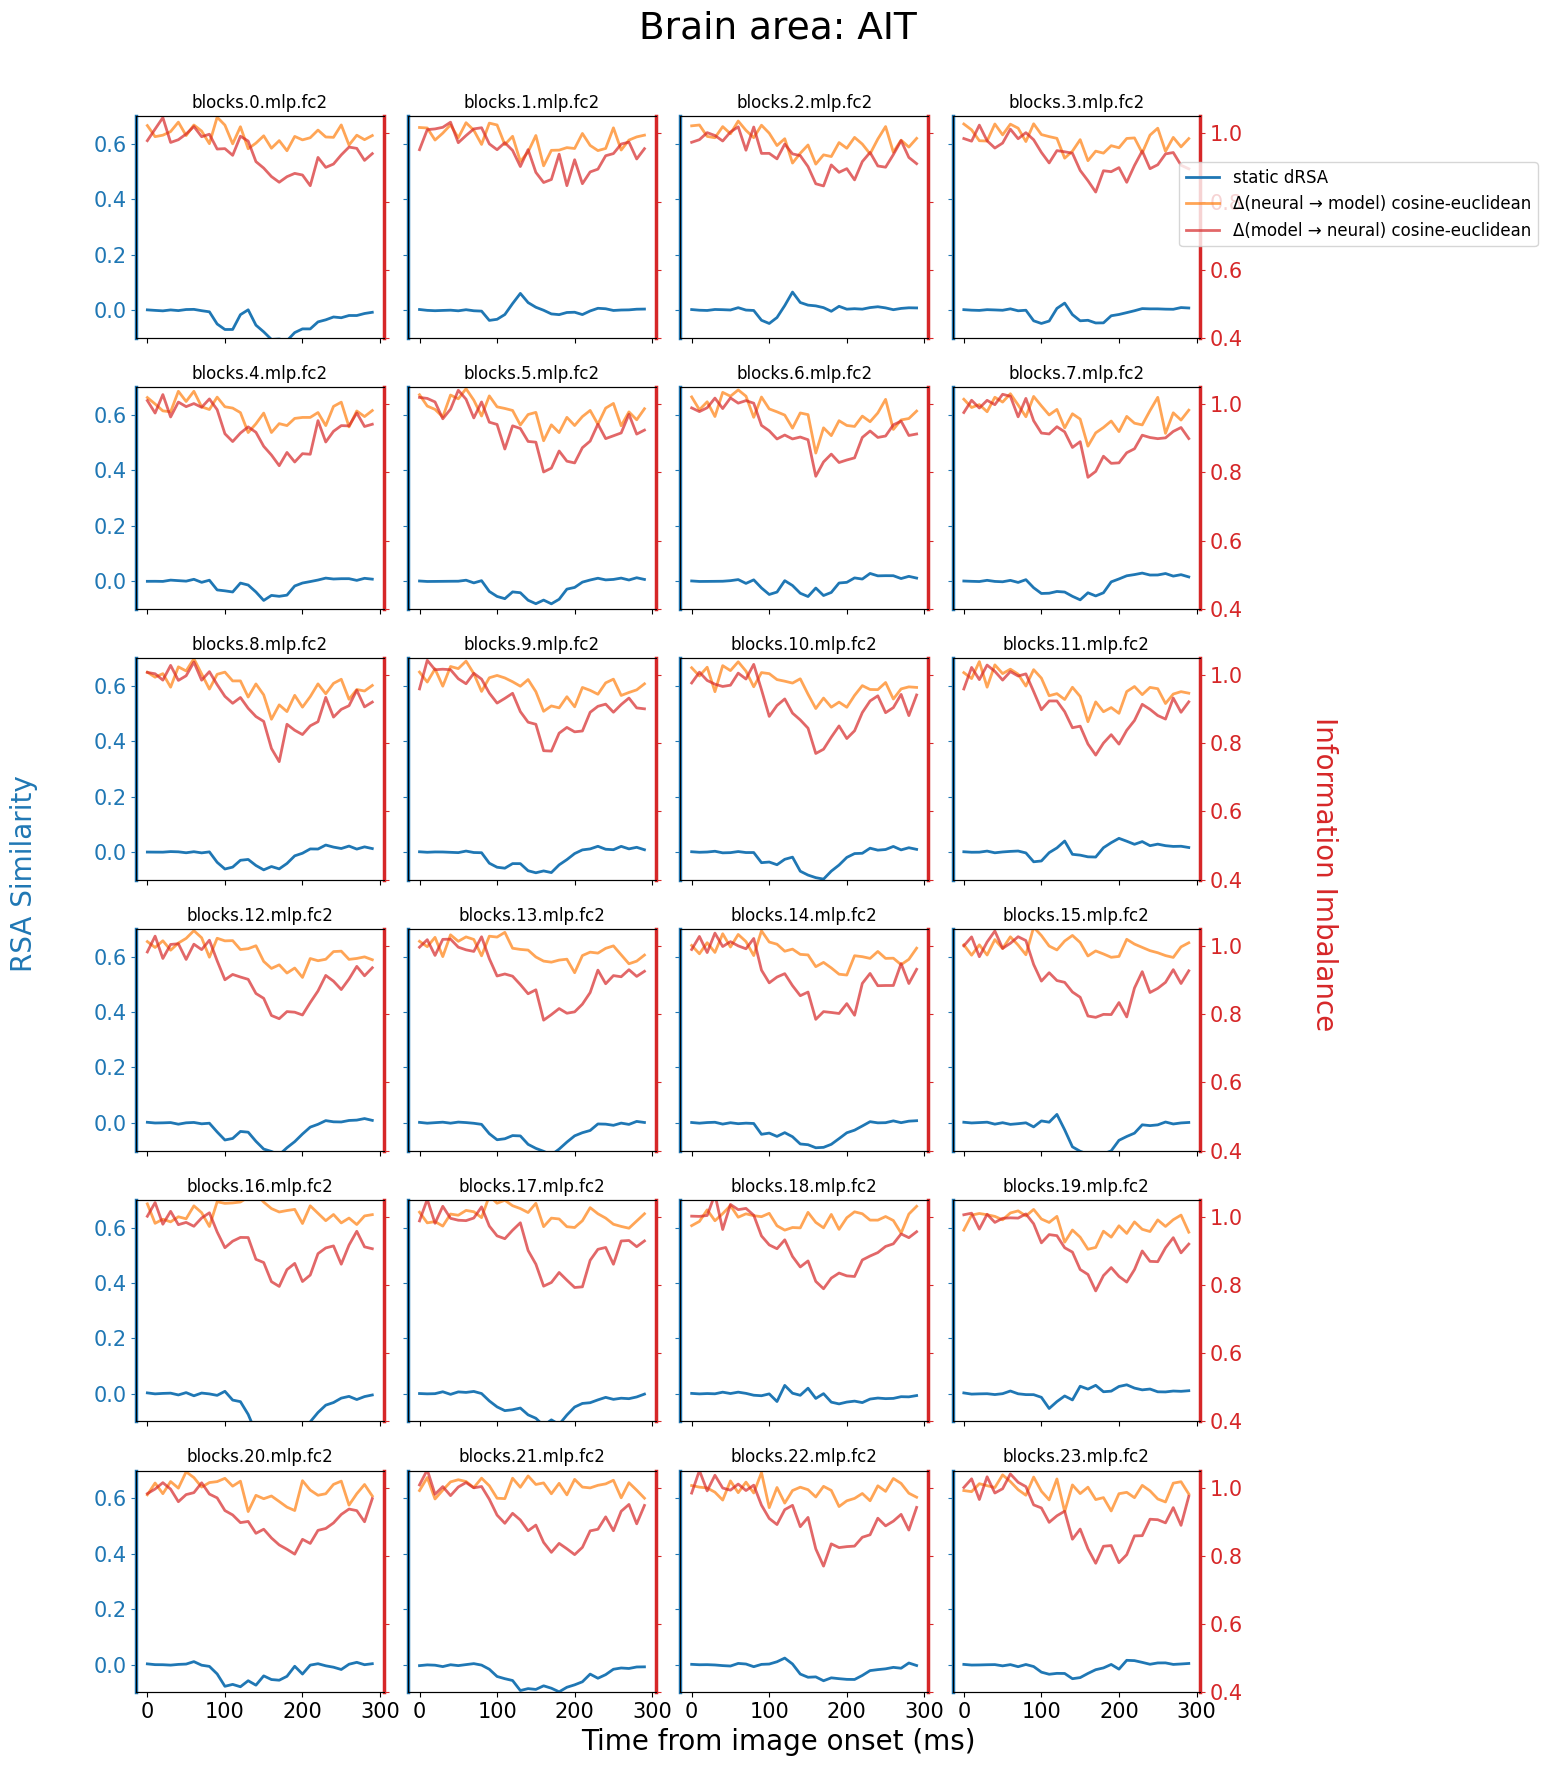

In [50]:
cfg.signal_RDM_metric = "cosine"
cfg.model_RDM_metric = "euclidean"
new_plot_metrics(paths, layers, cfg, ylim=[-.1, .7])

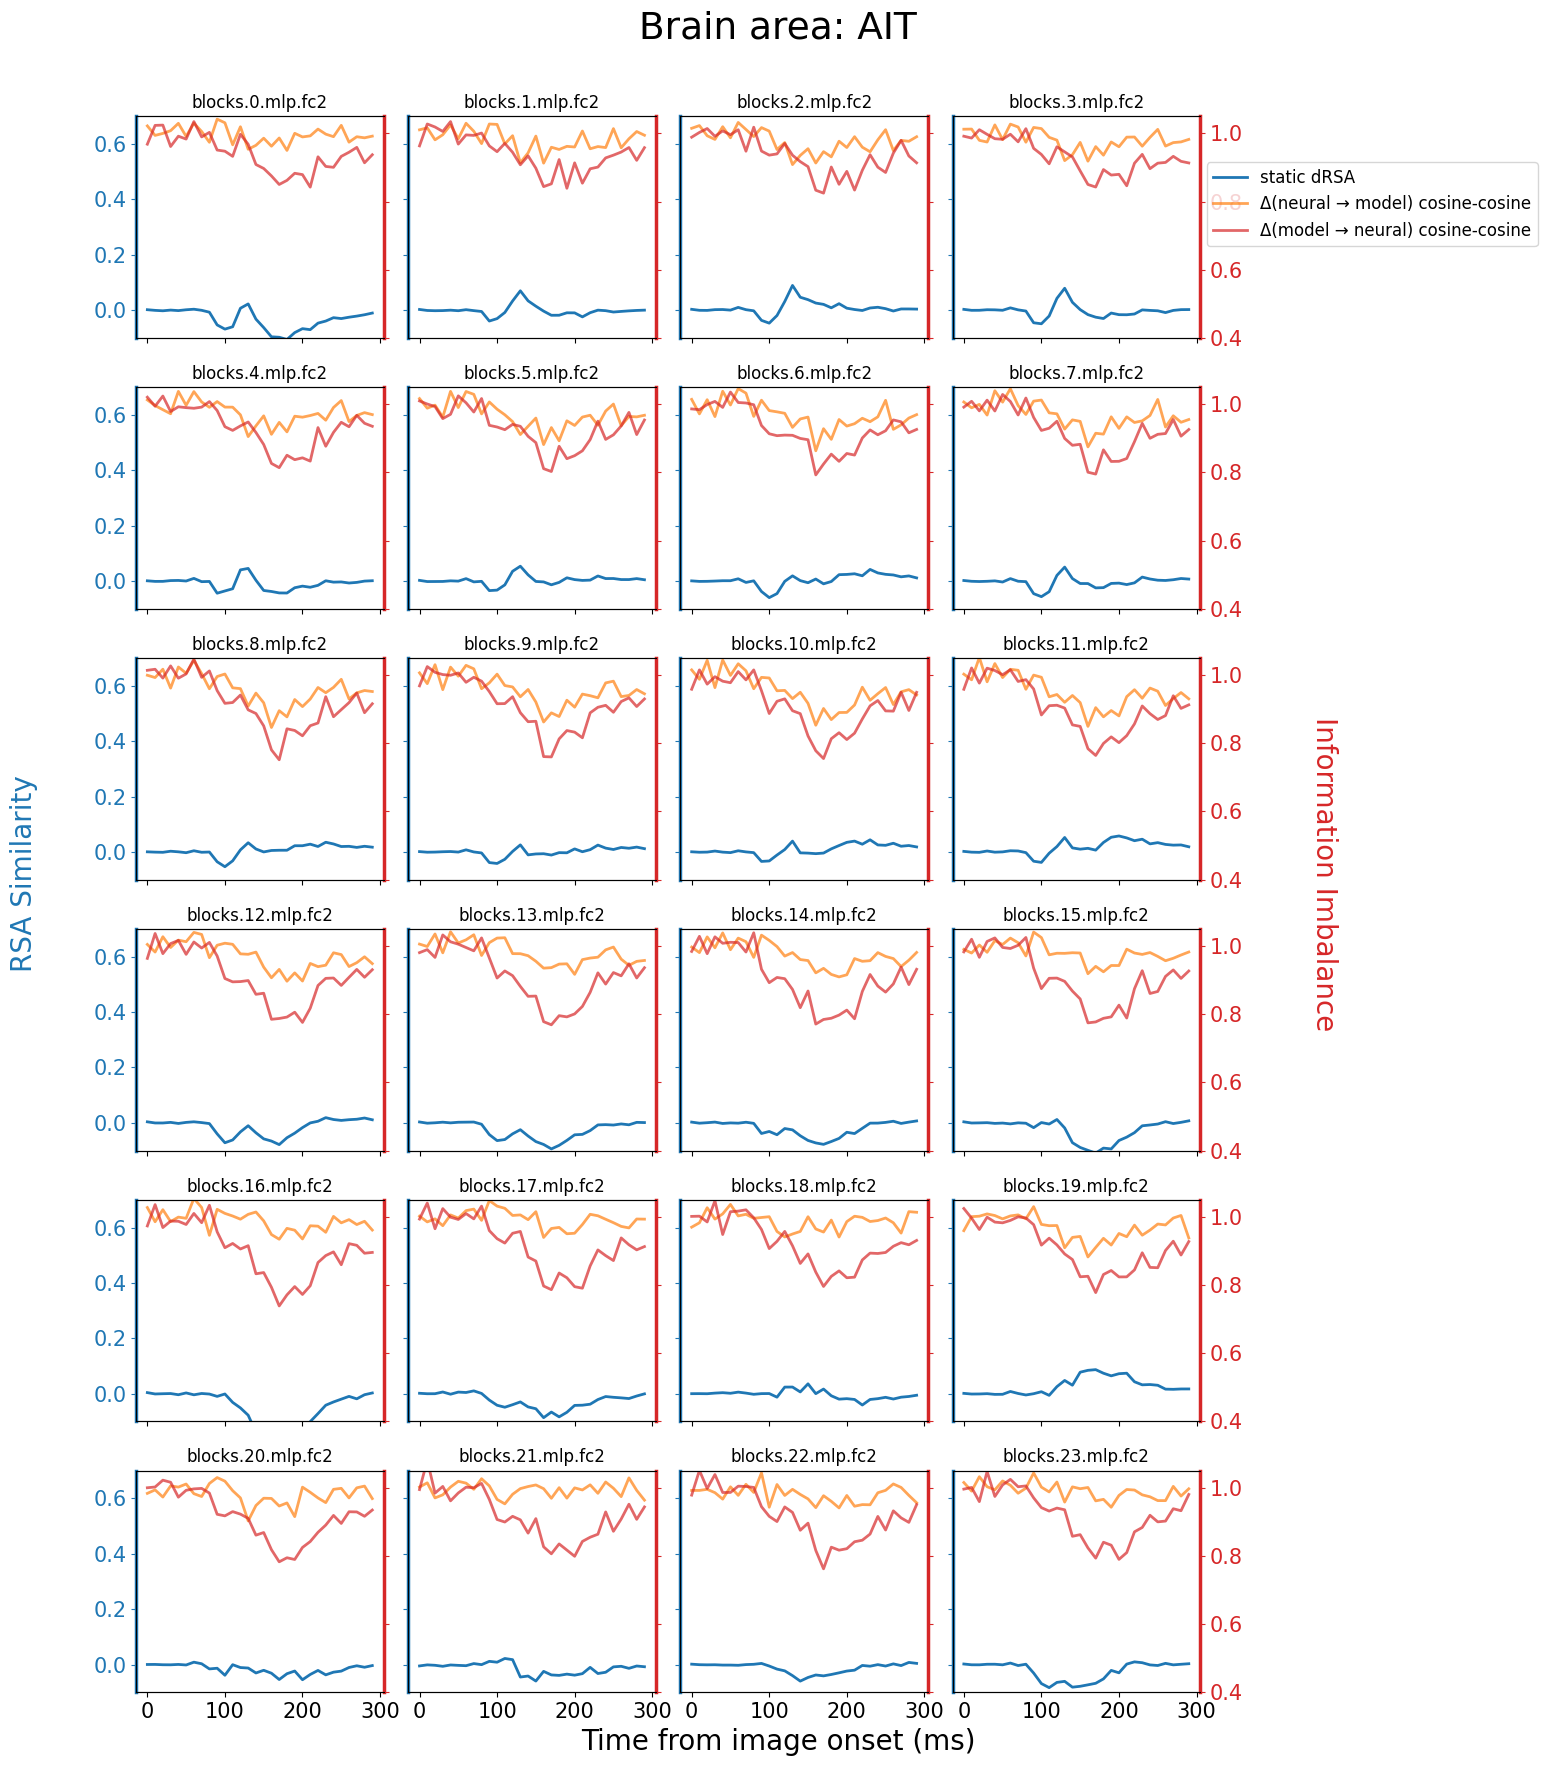

In [51]:
cfg.signal_RDM_metric = "cosine"
cfg.model_RDM_metric = "cosine"
new_plot_metrics(paths, layers, cfg, ylim=[-.1, .7])

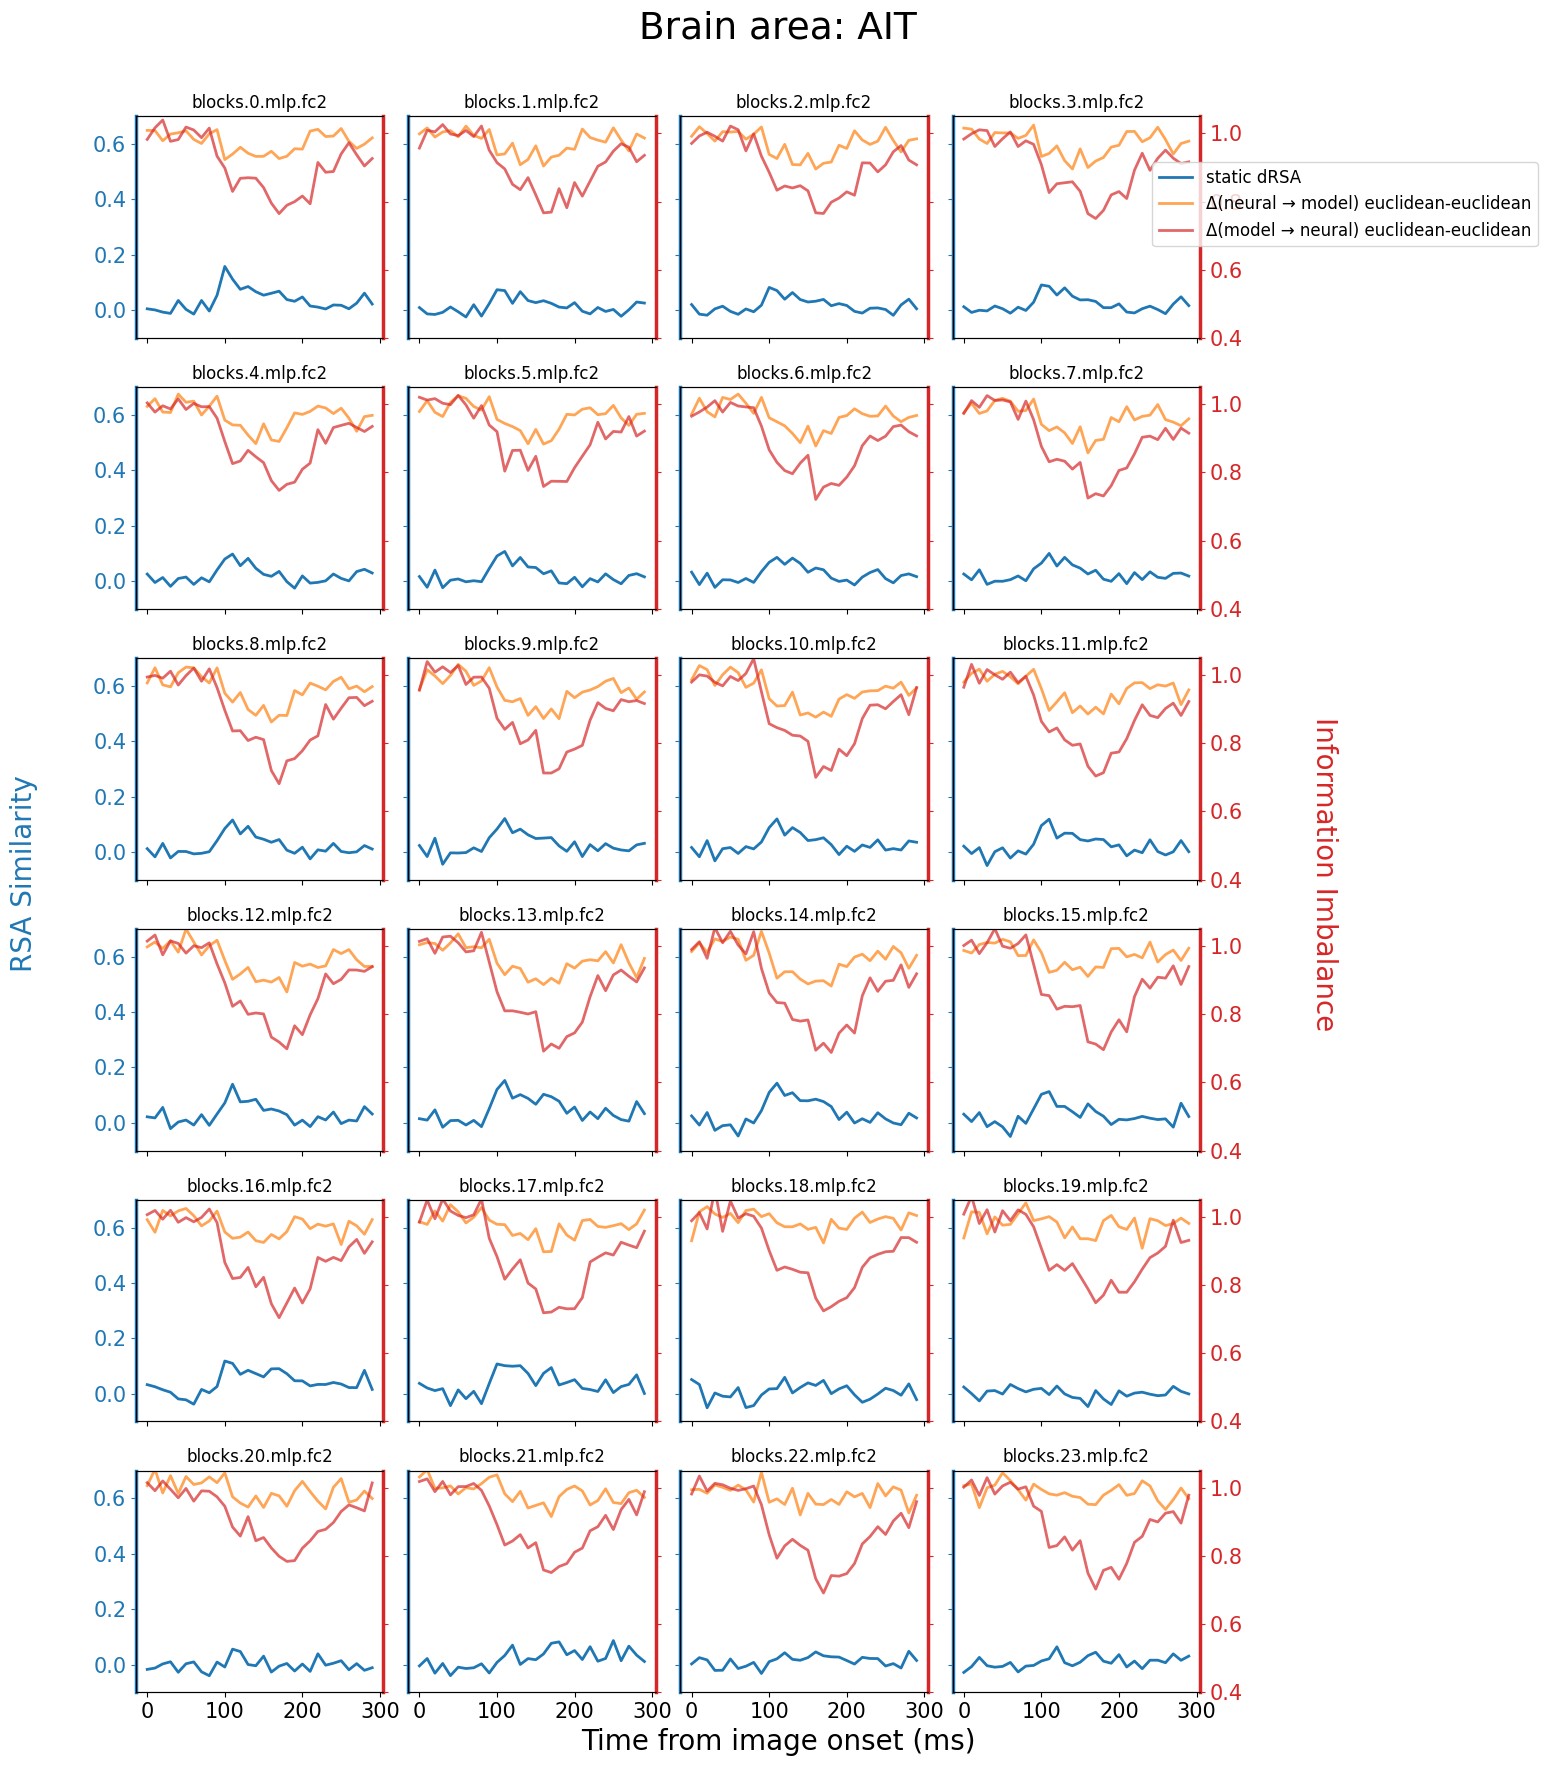

In [57]:
cfg.signal_RDM_metric = "euclidean"
cfg.model_RDM_metric = "euclidean"
new_plot_metrics(paths, layers, cfg, ylim=[-.1, .7])

In [102]:
def load_and_plot_dRSA(paths, cfg, i_mt, j_mt, idx, l, ax, ncols, color):
    save_name_dRSA = f"{paths['livingstone_lab']}/tiziano/results/static_dRSA_{i_mt}-{j_mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"    
    drsa = np.load(save_name_dRSA)["arr_0"]
    ax.set_title(l, fontsize=12)
    l_m1, = ax.plot(
        drsa,
        color=color,
        linestyle="-",
        linewidth=3,
    )
    
    ax.spines["left"].set_linewidth(2.5)
    color = "tab:blue"
    ax.spines["left"].set_color(color)
    ax.tick_params(axis="y", colors=color)
    ax.yaxis.label.set_color(color)

    ax_right = ax.twinx()
    color = "tab:red"
    ax_right.spines["right"].set_color(color)
    ax_right.tick_params(axis="y", colors=color)
    ax_right.yaxis.label.set_color(color)
    
    ax_right.spines["right"].set_linewidth(2.5)
    ax_right.set_ylim([.4, 1.05])
    if idx % ncols != ncols - 1:
        ax_right.set_yticks([.4, .6, .8, 1.0])
        ax_right.set_yticklabels([])
        ax_right.set_ylabel("")
    else:
        ax_right.tick_params(axis='both', labelsize=15)
    return l_m1, drsa


def plot_metrics_dRSA(paths, layers, cfg, ylim = None, save=False, colors=["tab:blue", "tab:cyan", "mediumseagreen", "tab:green"]):
    n_layers = len(layers)
    ncols = 4
    nrows = int(np.ceil(n_layers / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4*ncols, 3*nrows),
        sharex=True, sharey=True
    )
    axes = axes.flatten()
    

    for idx, (ax, l) in enumerate(zip(axes, layers)):
        handles = []
        labels = []
        counter = 0
        for i_mt in [cfg.RDM_metric1,cfg.RDM_metric2]:  
            for j_mt in [cfg.RDM_metric1,cfg.RDM_metric2]:  
                l_m, drsa = load_and_plot_dRSA(paths, cfg, i_mt, j_mt, idx, l, ax, ncols, colors[counter]) 
                counter +=1
                handles.append(l_m)
                labels.append(f"{i_mt}-{j_mt}")

    # remove unused axes
    for ax in axes[len(layers):]:
        ax.axis("off")

    fig.supxlabel("Time from image onset (ms)", fontsize=20)
    fig.supylabel("RSA Similarity", fontsize=20, color='tab:blue')
    fig.suptitle(f"Brain area: {cfg.brain_area}", fontsize=27)
    fig.tight_layout()

    fig.legend(handles, labels,fontsize=12, bbox_to_anchor=(0.98, 0.90))
    # make space on the right for the legend
    fig.tight_layout(rect=[0.03, 0, 0.80, .97])
    fig.text(
        0.85, 0.5,                  # x, y in figure coordinates
        "Information Imbalance",
        va="center",
        ha="right",
        rotation=-90,
        fontsize=20,
        color='tab:red'
    )
    # ax.set_xticks(xtickspos)           # positions of ticks
    # ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
    if ylim is not None:
        for ax in axes[:n_layers]:
            ax.set_ylim(ylim[0], ylim[1])
    xtickspos = range(0, len(drsa)+1, 10)       
    for ax in axes[:n_layers]:  # only the used axes
        ax.set_xticks(xtickspos)
        ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
        ax.tick_params(axis='both', labelsize=15)
        # ax_right = ax.twinx()
        # ax_right.tick_params(axis='right', labelsize=15)
    if save==True:
        return fig, axes
    else:
        plt.show()


In [103]:
def load_and_plot_II(paths, cfg, i_mt, j_mt, idx, l, ax, ncols, color):
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{cfg.k}_{i_mt}-{j_mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{cfg.k}_{i_mt}-{j_mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    A2B = np.load(save_name_A2B)["arr_0"]
    B2A = np.load(save_name_B2A)["arr_0"]
    ax.set_title(l, fontsize=12)
    ax_right = ax.twinx()
    l_m1, = ax_right.plot(
        A2B,
        color=color,
        linestyle="--",
        linewidth=2,
    )
    
    l_m2, = ax_right.plot(
        B2A,
        color=color,
        linestyle="-",
        linewidth=2,
    )
    ax.spines["left"].set_linewidth(2.5)
    color = "tab:blue"
    ax.spines["left"].set_color(color)
    ax.tick_params(axis="y", colors=color)
    ax.yaxis.label.set_color(color)

    color = "tab:red"
    ax_right.spines["right"].set_color(color)
    ax_right.tick_params(axis="y", colors=color)
    ax_right.yaxis.label.set_color(color)
    
    ax_right.spines["right"].set_linewidth(2.5)
    ax_right.set_ylim([.4, 1.05])
    if idx % ncols != ncols - 1:
        ax_right.set_yticks([.4, .6, .8, 1.0])
        ax_right.set_yticklabels([])
        ax_right.set_ylabel("")
    else:
        ax_right.tick_params(axis='both', labelsize=15)
    return l_m1, l_m2, A2B


def plot_metrics_II(paths, layers, cfg, ylim = None, save=False, colors=["tab:blue", "tab:cyan", "mediumseagreen", "tab:green"]):
    n_layers = len(layers)
    ncols = 4
    nrows = int(np.ceil(n_layers / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4*ncols, 3*nrows),
        sharex=True, sharey=True
    )
    axes = axes.flatten()
    

    for idx, (ax, l) in enumerate(zip(axes, layers)):
        handles = []
        labels = []
        counter = 0
        for i_mt in [cfg.RDM_metric1,cfg.RDM_metric2]:  
            for j_mt in [cfg.RDM_metric1,cfg.RDM_metric2]:  
                l_m_A2B, l_m_B2A, ii = load_and_plot_II(paths, cfg, i_mt, j_mt, idx, l, ax, ncols, colors[counter]) 
                counter +=1
                handles.append(l_m_A2B)
                handles.append(l_m_B2A)
                labels.append(f"neural->model {i_mt}-{j_mt} ")
                labels.append(f"model->neural {i_mt}-{j_mt}")

    # remove unused axes
    for ax in axes[len(layers):]:
        ax.axis("off")

    fig.supxlabel("Time from image onset (ms)", fontsize=20)
    fig.supylabel("RSA Similarity", fontsize=20, color='tab:blue')
    fig.suptitle(f"Brain area: {cfg.brain_area}", fontsize=27)
    fig.tight_layout()

    fig.legend(handles, labels,fontsize=12, bbox_to_anchor=(0.98, 0.90))
    # make space on the right for the legend
    fig.tight_layout(rect=[0.03, 0, 0.80, .97])
    fig.text(
        0.85, 0.5,                  # x, y in figure coordinates
        "Information Imbalance",
        va="center",
        ha="right",
        rotation=-90,
        fontsize=20,
        color='tab:red'
    )
    # ax.set_xticks(xtickspos)           # positions of ticks
    # ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
    if ylim is not None:
        for ax in axes[:n_layers]:
            ax.set_ylim(ylim[0], ylim[1])
    xtickspos = range(0, len(ii)+1, 10)       
    for ax in axes[:n_layers]:  # only the used axes
        ax.set_xticks(xtickspos)
        ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
        ax.tick_params(axis='both', labelsize=15)
        # ax_right = ax.twinx()
        # ax_right.tick_params(axis='right', labelsize=15)
    if save==True:
        return fig, axes
    else:
        plt.show()


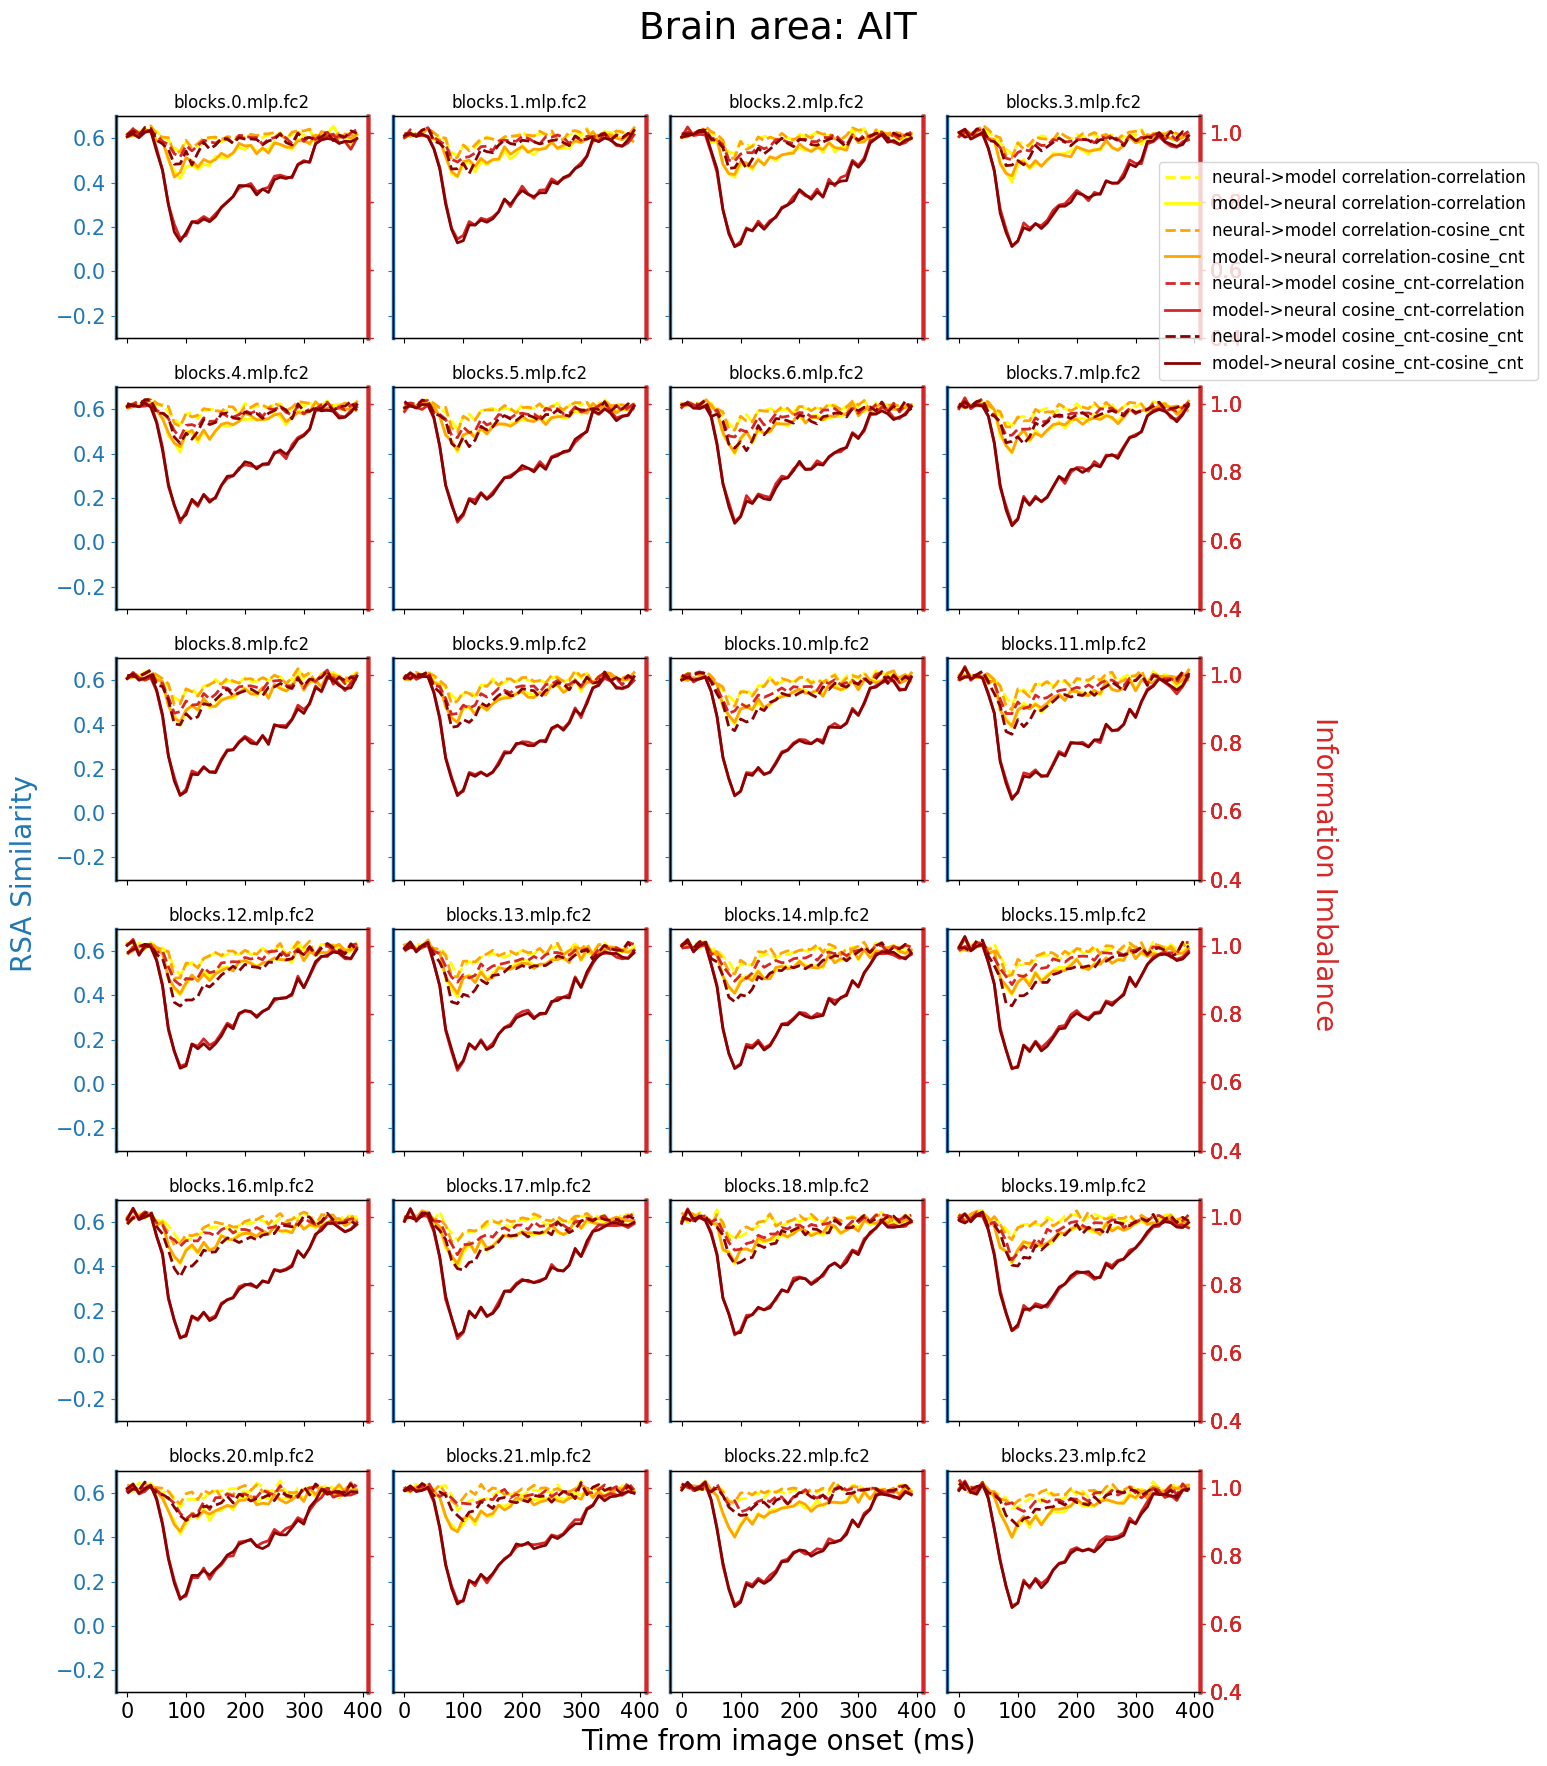

In [122]:
plot_metrics_II(paths, layers, cfg, ylim=[-.3, .7], colors= ["darkred", "tab:red", "orange", "yellow"][::-1])

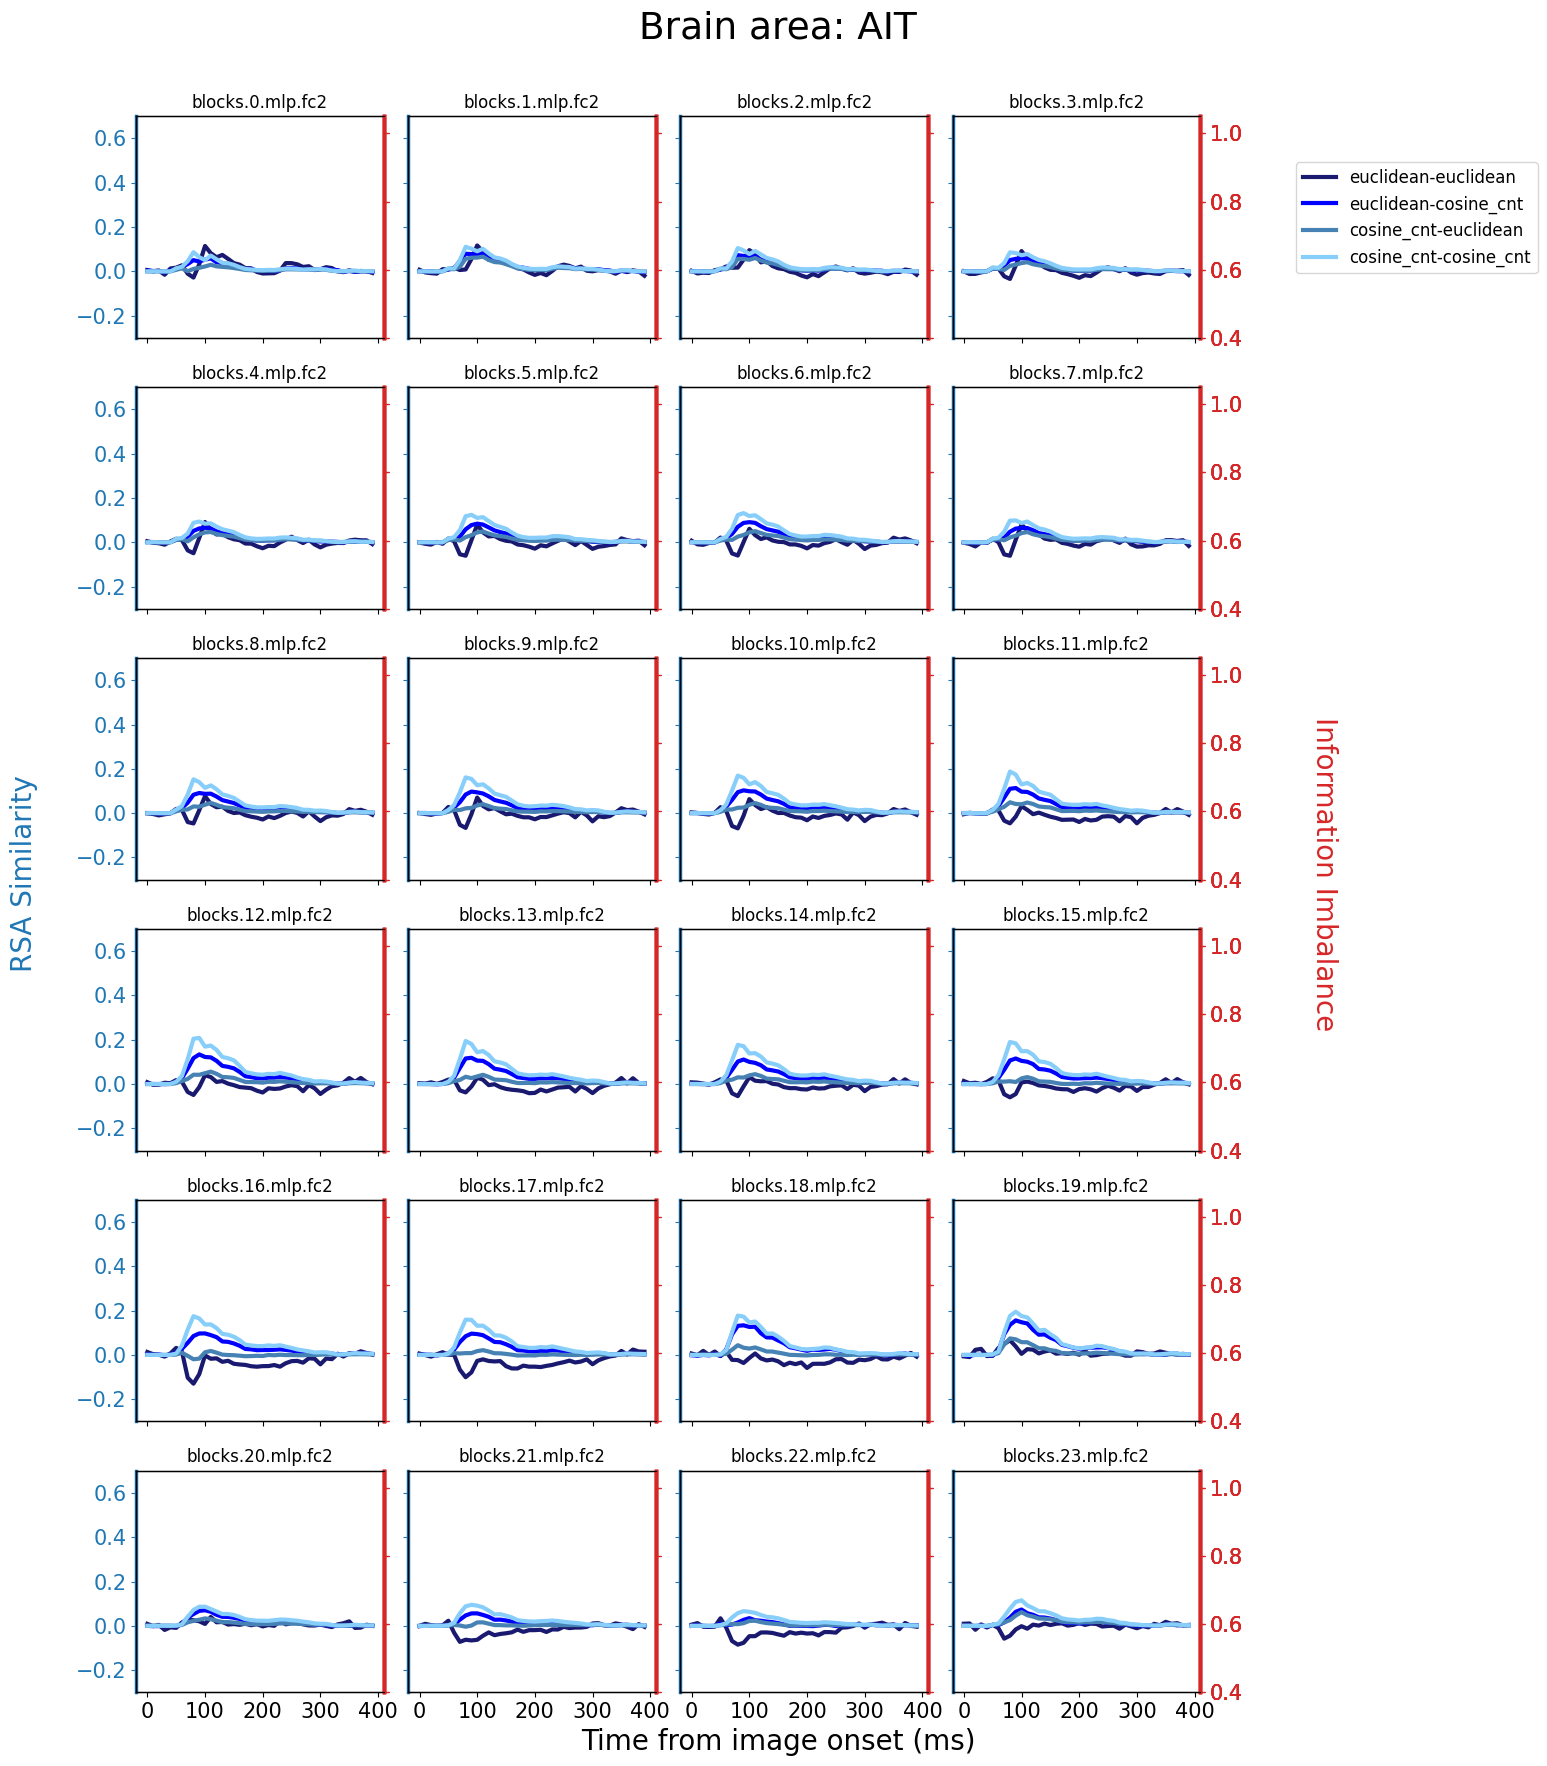

In [127]:
plot_metrics_dRSA(paths, layers, cfg, ylim=[-.3, .7], colors= ["midnightblue","blue","steelblue", "lightskyblue",])